# Stochastic refinement with an ensemble validation set

This standalone rerun compares the same five-member forward- and backward-knee
SVM sets at 0, 10, 20, 50, and 100 refinement steps. Every nonzero budget is
tested with one-model and all-model joint proposals. Unlike the prior run,
stochastic acceptance and best-state tracking use a reserved ensemble-level
validation set. The blind set remains identical and untouched.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.15
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000 + seed,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            reduction_factor=0,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
for seed in INNER_SEEDS:
    for strategy in SELECTION_STRATEGIES:
        for num_models in MODEL_COUNTS:
            scaler, base_ensemble, knee_count = fit_knee_ensemble(
                strategy, num_models, seed
            )
            for steps in REFINEMENT_STEPS:
                update_modes = [False] if steps == 0 else [False, True]
                for update_all_models in update_modes:
                    candidate = copy.deepcopy(base_ensemble)
                    if steps:
                        candidate.stochastic_feature_selection(
                            parameter_grid(),
                            n_iterations=steps,
                            feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
                            set_for_rank="sample",
                            temperature=0.05,
                            cooling_rate=0.97,
                            add_probability=0.5,
                            random_seed=10_000 + 100 * num_models + seed,
                            update_all_models=update_all_models,
                            use_ensemble_validation=True,
                        )
                    rows.append(ensemble_row(
                        candidate, scaler, seed, strategy, num_models, steps,
                        knee_count, update_all_models,
                    ))
                    rows.append(reference_row(
                        candidate, seed, strategy, num_models, steps,
                        knee_count, update_all_models,
                    ))
                    print(
                        f"completed seed={seed}, strategy={strategy}, "
                        f"models={num_models}, steps={steps}, "
                        f"update_all_models={update_all_models}"
                    )
results = pd.DataFrame(rows)
results.to_csv(
    repo_root / "validation/Synthetic100_svmSet_stochastic_refinement_ensemble_validation_results.csv",
    index=False,
)
results.tail(12)

Loaded 108 completed cached rows for post-processing.


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,noise_fraction,member_disagreement,accepted_moves,roc_auc,f1,balanced_accuracy,accuracy
96,2,MiSTIC SVM set,backward_knee,20,False,ensemble_validation,5,15,34,0.55,0.45,0.2064,20.0,0.919255,0.796610,0.810947,0.808
97,2,sklearn on knee-ranked unified features,backward_knee,20,False,ensemble_validation,5,15,15,0.45,0.40,0.0000,NaN,0.902692,0.844828,0.857790,0.856
98,2,MiSTIC SVM set,backward_knee,20,True,ensemble_validation,5,15,40,0.55,0.45,0.1856,18.0,0.908385,0.800000,0.816511,0.816
99,2,sklearn on knee-ranked unified features,backward_knee,20,True,ensemble_validation,5,15,15,0.45,0.40,0.0000,NaN,0.902692,0.844828,0.857790,0.856
100,2,MiSTIC SVM set,backward_knee,50,False,ensemble_validation,5,15,34,0.55,0.45,0.2064,46.0,0.919255,0.796610,0.810947,0.808
101,2,sklearn on knee-ranked unified features,backward_knee,50,False,ensemble_validation,5,15,15,0.45,0.40,0.0000,NaN,0.902692,0.844828,0.857790,0.856
102,2,MiSTIC SVM set,backward_knee,50,True,ensemble_validation,5,15,40,0.55,0.45,0.1856,40.0,0.908385,0.800000,0.816511,0.816
103,2,sklearn on knee-ranked unified features,backward_knee,50,True,ensemble_validation,5,15,15,0.45,0.40,0.0000,NaN,0.902692,0.844828,0.857790,0.856
104,2,MiSTIC SVM set,backward_knee,100,False,ensemble_validation,5,15,49,0.55,0.45,0.2368,82.0,0.917443,0.807339,0.827640,0.832
105,2,sklearn on knee-ranked unified features,backward_knee,100,False,ensemble_validation,5,15,15,0.45,0.40,0.0000,NaN,0.931418,0.879310,0.890140,0.888


## Blind-set performance

In [5]:
metric_columns = ["roc_auc", "f1", "balanced_accuracy", "accuracy"]
summary = (
    results.groupby(["method", "selection_strategy", "num_models", "refinement_steps", "update_all_models"])
    .agg(
        **{f"mean_{metric}": (metric, "mean") for metric in metric_columns},
        **{f"sd_{metric}": (metric, "std") for metric in metric_columns},
        mean_feature_count=("num_unified_features", "mean"),
        mean_signal_recall=("signal_recall", "mean"),
        mean_noise_fraction=("noise_fraction", "mean"),
        mean_accepted_moves=("accepted_moves", "mean"),
    )
    .round(4)
)
summary

mean_roc_auc  \
method                                  selection_strategy num_models refinement_steps update_all_models                 
MiSTIC SVM set                          backward_knee      5          0                False                    0.9172   
                                                                      10               False                    0.9174   
                                                                                       True                     0.9125   
                                                                      20               False                    0.9167   
                                                                                       True                     0.9125   
                                                                      50               False                    0.9167   
                                                                                       True                     0.9142   
                                                                      100              False                    0.9188   
                                                                                       True                     0.9125   
                                        forward_knee       5          0                False                    0.9009   
                                                                      10               False                    0.9054   
                                                                                       True                     0.9061   
                                                                      20               False                    0.9053   
                                                                                       True                     0.9061   
                                                                      50               False                    0.9096   
                                                                                       True                     0.9131   
                                                                      100              False                    0.9192   
                                                                                       True                     0.9262   
sklearn on knee-ranked unified features backward_knee      5          0                False                    0.9066   
                                                                      10               False                    0.9066   
                                                                                       True                     0.9066   
                                                                      20               False                    0.9066   
                                                                                       True                     0.9066   
                                                                      50               False                    0.9066   
                                                                                       True                     0.9136   
                                                                      100              False                    0.9161   
                                                                                       True                     0.9066   
                                        forward_knee       5          0                False                    0.8537   
                                                                      10               False                    0.8537   
                                                                                       True                     0.8537   
                                                                      20               False                    0.8537   
                                                                                

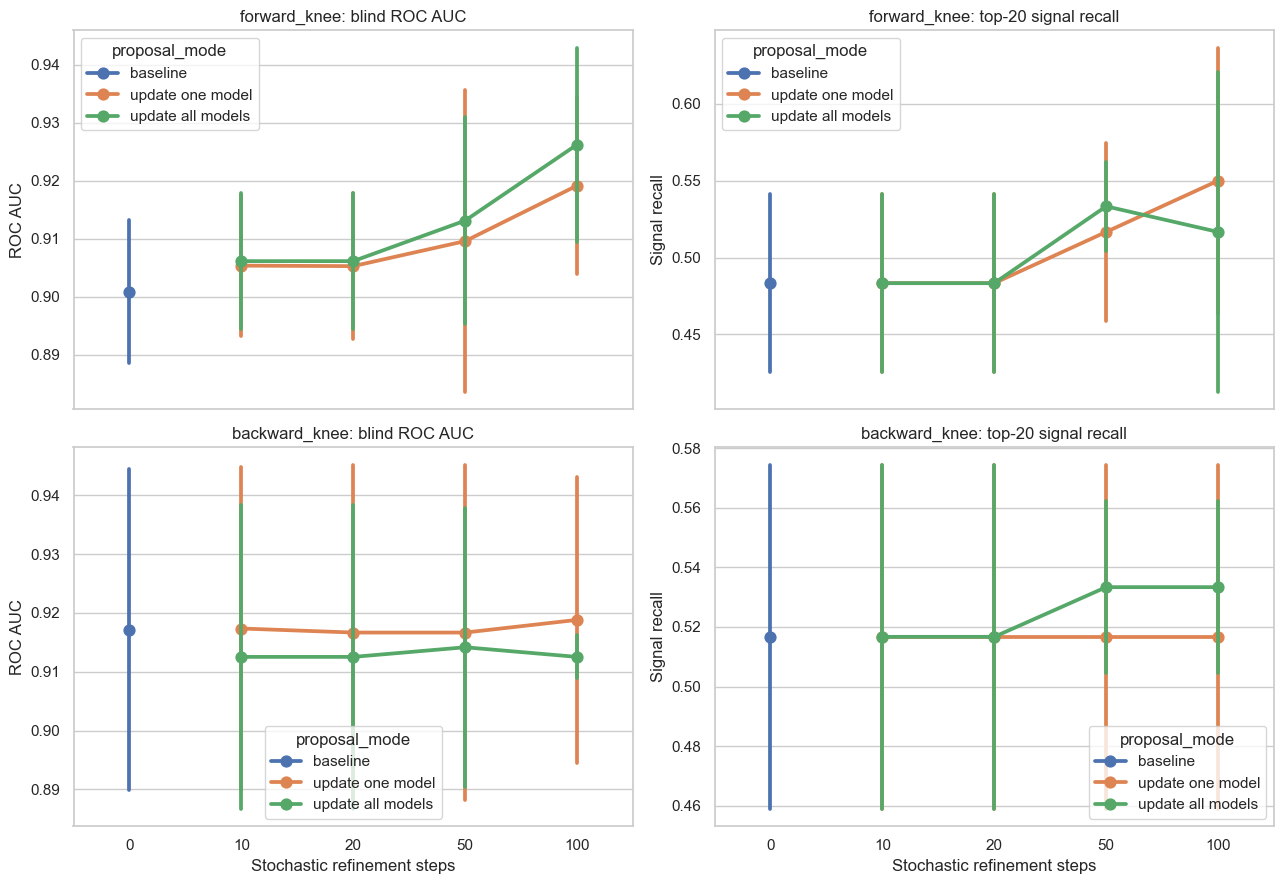

In [6]:
plot_results = results.query("method == 'MiSTIC SVM set'").copy()
plot_results["proposal_mode"] = np.where(
    plot_results["refinement_steps"] == 0,
    "baseline",
    np.where(plot_results["update_all_models"], "update all models", "update one model"),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for row_index, strategy in enumerate(SELECTION_STRATEGIES):
    subset = plot_results.query("selection_strategy == @strategy")
    sns.pointplot(
        data=subset, x="refinement_steps", y="roc_auc",
        hue="proposal_mode", errorbar="sd", ax=axes[row_index, 0],
    )
    axes[row_index, 0].set(
        title=f"{strategy}: blind ROC AUC",
        xlabel="Stochastic refinement steps",
        ylabel="ROC AUC",
    )
    sns.pointplot(
        data=subset, x="refinement_steps", y="signal_recall",
        hue="proposal_mode", errorbar="sd", ax=axes[row_index, 1],
    )
    axes[row_index, 1].set(
        title=f"{strategy}: top-20 signal recall",
        xlabel="Stochastic refinement steps",
        ylabel="Signal recall",
    )
plt.tight_layout()

## Paired change from no refinement

Positive deltas favor stochastic refinement. Pairing by seed ensures the
comparison never mixes blind sets or inner split seeds.

In [7]:
mistic_results = results.query("method == 'MiSTIC SVM set'").copy()
baseline = mistic_results.query("refinement_steps == 0").set_index(
    ["seed", "selection_strategy", "num_models"]
)
paired_rows = []
for steps in [10, 20, 50, 100]:
    for update_all_models in [False, True]:
        refined = mistic_results.query(
            "refinement_steps == @steps and update_all_models == @update_all_models"
        ).set_index(["seed", "selection_strategy", "num_models"])
        for index in refined.index:
            paired_rows.append({
                "seed": index[0],
                "selection_strategy": index[1],
                "num_models": index[2],
                "refinement_steps": steps,
                "update_all_models": update_all_models,
                "delta_roc_auc": refined.loc[index, "roc_auc"] - baseline.loc[index, "roc_auc"],
                "delta_f1": refined.loc[index, "f1"] - baseline.loc[index, "f1"],
                "delta_signal_recall": refined.loc[index, "signal_recall"] - baseline.loc[index, "signal_recall"],
                "delta_union_size": refined.loc[index, "num_unified_features"] - baseline.loc[index, "num_unified_features"],
            })
paired = pd.DataFrame(paired_rows)
paired.groupby([
    "selection_strategy", "num_models", "refinement_steps", "update_all_models"
]).agg(
    mean_delta_auc=("delta_roc_auc", "mean"),
    wins_auc=("delta_roc_auc", lambda values: int((values > 0).sum())),
    mean_delta_f1=("delta_f1", "mean"),
    mean_delta_recall=("delta_signal_recall", "mean"),
    mean_delta_union=("delta_union_size", "mean"),
).round(4)

mean_delta_auc  \
selection_strategy num_models refinement_steps update_all_models                   
backward_knee      5          10               False                      0.0002   
                                               True                      -0.0047   
                              20               False                     -0.0005   
                                               True                      -0.0047   
                              50               False                     -0.0005   
                                               True                      -0.0030   
                              100              False                      0.0016   
                                               True                      -0.0047   
forward_knee       5          10               False                      0.0045   
                                               True                       0.0053   
                              20               False                      0.0044   
                                               True                       0.0053   
                              50               False                      0.0087   
                                               True                       0.0122   
                              100              False                      0.0183   
                                               True                       0.0254   

                                                                  wins_auc  \
selection_strategy num_models refinement_steps update_all_models             
backward_knee      5          10               False                     1   
                                               True                      0   
                              20               False                     1   
                                               True                      0   
                              50               False                     1   
                                               True                      1   
                              100              False                     2   
                                               True                      1   
forward_knee       5          10               False                     1   
                                               True                      1   
                              20               False                     1   
                                               True                      1   
                              50               False                     2   
                                               True                      3   
                              100              False                     2   
                                               True                      3   

                                                                  mean_delta_f1  \
selection_strategy num_models refinement_steps update_all_models                  
backward_knee      5          10               False                     0.0004   
                                               True                      0.0107   
                              20               False                    -0.0135   
                                               True                      0.0107   
                              50               False                    -0.0135   
                                               True                     -0.0091   
                              100              False                    -0.0043   
                                               True                     -0.0147   
forward_knee       5          10               False                     0.0109   
                                               True                      0.0165   
                              20               False                     0.0006   
                                               True                  

## Interpretation

The primary evidence for refinement is the paired blind-set AUC change relative
to zero steps. Feature recovery and union size show whether any performance
change comes with a clearer or more diffuse selected signal. The sklearn rows
are matched references, retrained independently on the top unified-ranked
features capped at the original greedy knee count.

## Comparison with the prior CV-objective refinement

The historical run uses average member cross-validation score for stochastic
acceptance and best-state tracking. Rows are paired by seed, selection
direction, iteration budget, and proposal mode. Positive deltas favor the new
ensemble-validation objective.

In [8]:
historical_results = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_stochastic_refinement_results.csv"
)
match_columns = [
    "seed", "method", "selection_strategy", "num_models",
    "refinement_steps", "update_all_models",
]
comparison = results.merge(
    historical_results,
    on=match_columns,
    suffixes=("_ensemble_validation", "_historical_cv"),
)
for metric in ["roc_auc", "f1", "balanced_accuracy", "accuracy", "signal_recall", "num_unified_features"]:
    comparison[f"delta_{metric}"] = (
        comparison[f"{metric}_ensemble_validation"]
        - comparison[f"{metric}_historical_cv"]
    )

comparison.query("method == 'MiSTIC SVM set'").groupby([
    "selection_strategy", "refinement_steps", "update_all_models"
]).agg(
    ensemble_validation_auc=("roc_auc_ensemble_validation", "mean"),
    historical_auc=("roc_auc_historical_cv", "mean"),
    mean_delta_auc=("delta_roc_auc", "mean"),
    auc_wins=("delta_roc_auc", lambda values: int((values > 0).sum())),
    mean_delta_f1=("delta_f1", "mean"),
    mean_delta_signal_recall=("delta_signal_recall", "mean"),
    mean_delta_union_size=("delta_num_unified_features", "mean"),
).round(4)

ensemble_validation_auc  \
selection_strategy refinement_steps update_all_models                            
backward_knee      0                False                               0.9172   
                   10               False                               0.9174   
                                    True                                0.9125   
                   20               False                               0.9167   
                                    True                                0.9125   
                   50               False                               0.9167   
                                    True                                0.9142   
                   100              False                               0.9188   
                                    True                                0.9125   
forward_knee       0                False                               0.9009   
                   10               False                               0.9054   
                                    True                                0.9061   
                   20               False                               0.9053   
                                    True                                0.9061   
                   50               False                               0.9096   
                                    True                                0.9131   
                   100              False                               0.9192   
                                    True                                0.9262   

                                                       historical_auc  \
selection_strategy refinement_steps update_all_models                   
backward_knee      0                False                      0.9207   
                   10               False                      0.9223   
                                    True                       0.9200   
                   20               False                      0.9223   
                                    True                       0.9200   
                   50               False                      0.9223   
                                    True                       0.9200   
                   100              False                      0.9223   
                                    True                       0.9170   
forward_knee       0                False                      0.9499   
                   10               False                      0.9490   
                                    True                       0.9492   
                   20               False                      0.9488   
                                    True                       0.9492   
                   50               False                      0.9515   
                                    True                       0.9492   
                   100              False                      0.9396   
                                    True                       0.9425   

                                                       mean_delta_auc  \
selection_strategy refinement_steps update_all_models                   
backward_knee      0                False                     -0.0035   
                   10               False                     -0.0049   
                                    True                      -0.0075   
                   20               False                     -0.0056   
                                    True                      -0.0075   
                   50               False                     -0.0056   
                                    True                      -0.0059   
                   100              False                     -0.0035   
                                    True                      -0.0045   
forward_knee       0                False                     -0.0490   
                   10               False                     -0.0437   
    

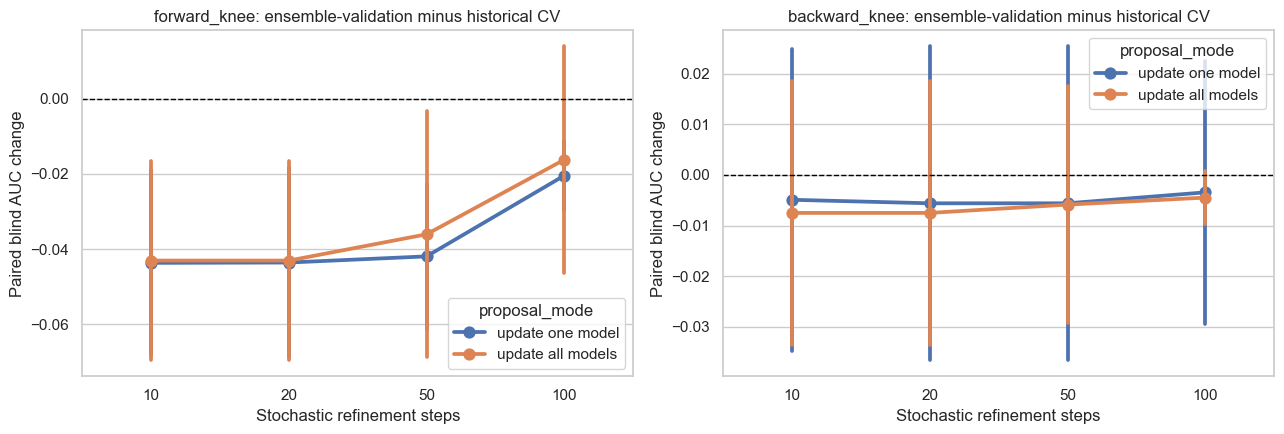

In [9]:
mistic_comparison = comparison.query("method == 'MiSTIC SVM set' and refinement_steps > 0").copy()
mistic_comparison["proposal_mode"] = np.where(
    mistic_comparison["update_all_models"], "update all models", "update one model"
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, strategy in zip(axes, SELECTION_STRATEGIES):
    sns.pointplot(
        data=mistic_comparison.query("selection_strategy == @strategy"),
        x="refinement_steps", y="delta_roc_auc", hue="proposal_mode",
        errorbar="sd", ax=axis,
    )
    axis.axhline(0, color="black", linewidth=1, linestyle="--")
    axis.set(
        title=f"{strategy}: ensemble-validation minus historical CV",
        xlabel="Stochastic refinement steps", ylabel="Paired blind AUC change",
    )
plt.tight_layout()